**Данные, с которыми работает пайплайн**

### Вход
- `baseline_blocks.pickle` — кварталы до проекта.
- `scenario_blocks.pickle` — сценарные кварталы после реализации.
- `context_blocks.pickle` — контекстные кварталы города для учета соседних характеристик.



In [1]:
import pandas as pd
baseline_blocks = pd.read_pickle('./data/baseline_blocks.pickle')
scenario_blocks = pd.read_pickle('./data/scenario_blocks.pickle')
context_blocks = pd.read_pickle('./data/context_blocks.pickle')

In [2]:
baseline_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((391069.678 6644283.933, 391050.241 6...",0.618414,0.044475,0.160341,0.0,0.0,0.001839,0.0,LandUse.RESIDENTIAL,0.618414
1,"POLYGON ((391050.241 6644214.883, 391069.678 6...",1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000
2,"POLYGON ((390977.168 6643926.423, 390992.271 6...",0.860749,0.000000,0.139251,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,0.860749
3,"POLYGON ((390992.271 6644001.941, 391006.969 6...",1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000
4,"POLYGON ((390959.455 6643851.451, 390977.168 6...",0.000000,0.737552,0.262448,0.0,0.0,0.000000,0.0,LandUse.BUSINESS,0.737552


In [3]:
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [4]:
context_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_supermarket,count_supermarket,capacity_swimming_pool,count_swimming_pool,capacity_train_station,count_train_station,capacity_university,count_university,capacity_veterinary,count_veterinary
0,"POLYGON ((391549.648 6642620.924, 391440.516 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,5000,1,1000,1,0,0,0,0,0,0
1,"POLYGON ((390728.805 6642824.074, 390766.253 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
2,"POLYGON ((384619.942 6643780.507, 384592.897 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
3,"POLYGON ((383701.245 6643709.235, 384459.417 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
4,"POLYGON ((394792.785 6641449.688, 394618.737 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0


In [5]:
m = baseline_blocks.explore(
    column='land_use',
    legend=True,
    style_kwds={
        "weight": 0.5,     # толщина границ
        "color": "black",  # цвет границ
        "fillOpacity": 0.7
    },
)

m

In [6]:
m = scenario_blocks.explore(
    column='land_use',
    legend=True,
    style_kwds={
        "weight": 0.5,     # толщина границ
        "color": "black",  # цвет границ
        "fillOpacity": 0.7
    },
)

m

## Данные по терртории до проекта

In [7]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=baseline_blocks,
    context_blocks_source=context_blocks,
)

basline_prepared_blocks = preparator.prepare()
basline_prepared_blocks.head()

2025-12-10 13:51:55.818 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.618414,0.044475,0.160341,0.0,0.0,0.001839,0.0,LandUse.RESIDENTIAL,0.618414,43743.312824,...,820351.893034,0.172159,0.053323,0.542771,3.228635,low-rise model,132.872848,True,"POLYGON ((391069.678 6644283.933, 391050.241 6...",0
1,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,11.720391,...,143.498624,0.241875,0.081676,0.578323,2.961395,low-rise model,135.391939,True,"POLYGON ((391050.241 6644214.883, 391069.678 6...",1
2,0.860749,0.000000,0.139251,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,0.860749,123.737389,...,708.434887,1.018722,0.174663,0.618815,5.832501,mid-rise,134.515316,True,"POLYGON ((390977.168 6643926.423, 390992.271 6...",2
3,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,62.624948,...,725.112337,0.277790,0.086366,0.629448,3.216435,low-rise model,134.633922,True,"POLYGON ((390992.271 6644001.941, 391006.969 6...",3
4,0.000000,0.737552,0.262448,0.0,0.0,0.000000,0.0,LandUse.BUSINESS,0.737552,79.773425,...,597.553304,0.309390,0.133500,0.000000,2.317526,low-rise non-residential,134.275676,True,"POLYGON ((390959.455 6643851.451, 390977.168 6...",4


## Данные по терртории после реализации проекта

In [8]:
preparator = LandDataPreparator(
    scenario_blocks_source=scenario_blocks,
    context_blocks_source=context_blocks,
)

scenario_prepared_blocks = preparator.prepare()
scenario_prepared_blocks.head()

2025-12-10 13:51:57.171 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


## Сохранение данных

In [9]:
basline_prepared_blocks.to_pickle('./data/baseline_prepared_blocks.pickle')
scenario_prepared_blocks.to_pickle('./data/scenario_prepared_blocks.pickle')


# Предсказание стоимости земли

## Загружаем данные

In [10]:
baseline_blocks = pd.read_pickle('./data/baseline_prepared_blocks.pickle')
scenario_blocks = pd.read_pickle('./data/scenario_prepared_blocks.pickle')

## Предсказываем стоимость земли до проекта

In [11]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator
model = CatBoostRegressor()

model.load_model('./data/catboost_model.cbm')


estimator = LandPriceEstimator(
    model=model,
    blocks=baseline_blocks,
)
baseline_blocks = estimator.predict()
baseline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id,land_value
0,0.618414,0.044475,0.160341,0.0,0.0,0.001839,0.0,LandUse.RESIDENTIAL,0.618414,43743.312824,...,0.172159,0.053323,0.542771,3.228635,low-rise model,132.872848,True,"POLYGON ((391069.678 6644283.933, 391050.241 6...",0,1.441196e+09
1,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,11.720391,...,0.241875,0.081676,0.578323,2.961395,low-rise model,135.391939,True,"POLYGON ((391050.241 6644214.883, 391069.678 6...",1,5.144069e+04
2,0.860749,0.000000,0.139251,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,0.860749,123.737389,...,1.018722,0.174663,0.618815,5.832501,mid-rise,134.515316,True,"POLYGON ((390977.168 6643926.423, 390992.271 6...",2,7.927111e+06
3,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,LandUse.RESIDENTIAL,1.000000,62.624948,...,0.277790,0.086366,0.629448,3.216435,low-rise model,134.633922,True,"POLYGON ((390992.271 6644001.941, 391006.969 6...",3,3.892235e+06
4,0.000000,0.737552,0.262448,0.0,0.0,0.000000,0.0,LandUse.BUSINESS,0.737552,79.773425,...,0.309390,0.133500,0.000000,2.317526,low-rise non-residential,134.275676,True,"POLYGON ((390959.455 6643851.451, 390977.168 6...",4,1.644465e+06



## Предсказываем стоимость земли после реализации проекта

In [12]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    blocks=scenario_blocks, #or baseline_blocks
)
scenario_blocks = estimator.predict()
scenario_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id,land_value
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0,1.889022e+08
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1,2.096246e+08
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2,1.502461e+08
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3,4.697694e+08
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4,4.721626e+04


## Получаем статистику

In [13]:
import geopandas as gpd
import pandas as pd

from urbanomy.methods.land_value_modeling import transfer_baseline_prices



blocks_full_value = transfer_baseline_prices(scenario_blocks, baseline_blocks)

blocks_full_value.to_pickle('./data/blocks_full_value.pickle')

# фильтруем только сценарные кварталы
scn_blocks = blocks_full_value.loc[blocks_full_value['is_project'] == True].copy()


sum_before = scn_blocks['land_value_before'].sum()
sum_after  = scn_blocks['land_value'].sum()

print(f"Сценарные кварталы — суммарная стоимость ДО застройки: {sum_before:,.0f} руб.")
print(f"Сценарные кварталы — суммарная стоимость ПОСЛЕ застройки: {sum_after:,.0f} руб.")

Сценарные кварталы — суммарная стоимость ДО застройки: 4,034,319,364 руб.
Сценарные кварталы — суммарная стоимость ПОСЛЕ застройки: 6,218,597,354 руб.


Суммарная стоимость (после застройки):
 • Сценические кварталы: 6 218 597 354 ₽
 • Контекст: 136 580 234 799 ₽
 • Все кварталы: 142 798 832 152 ₽


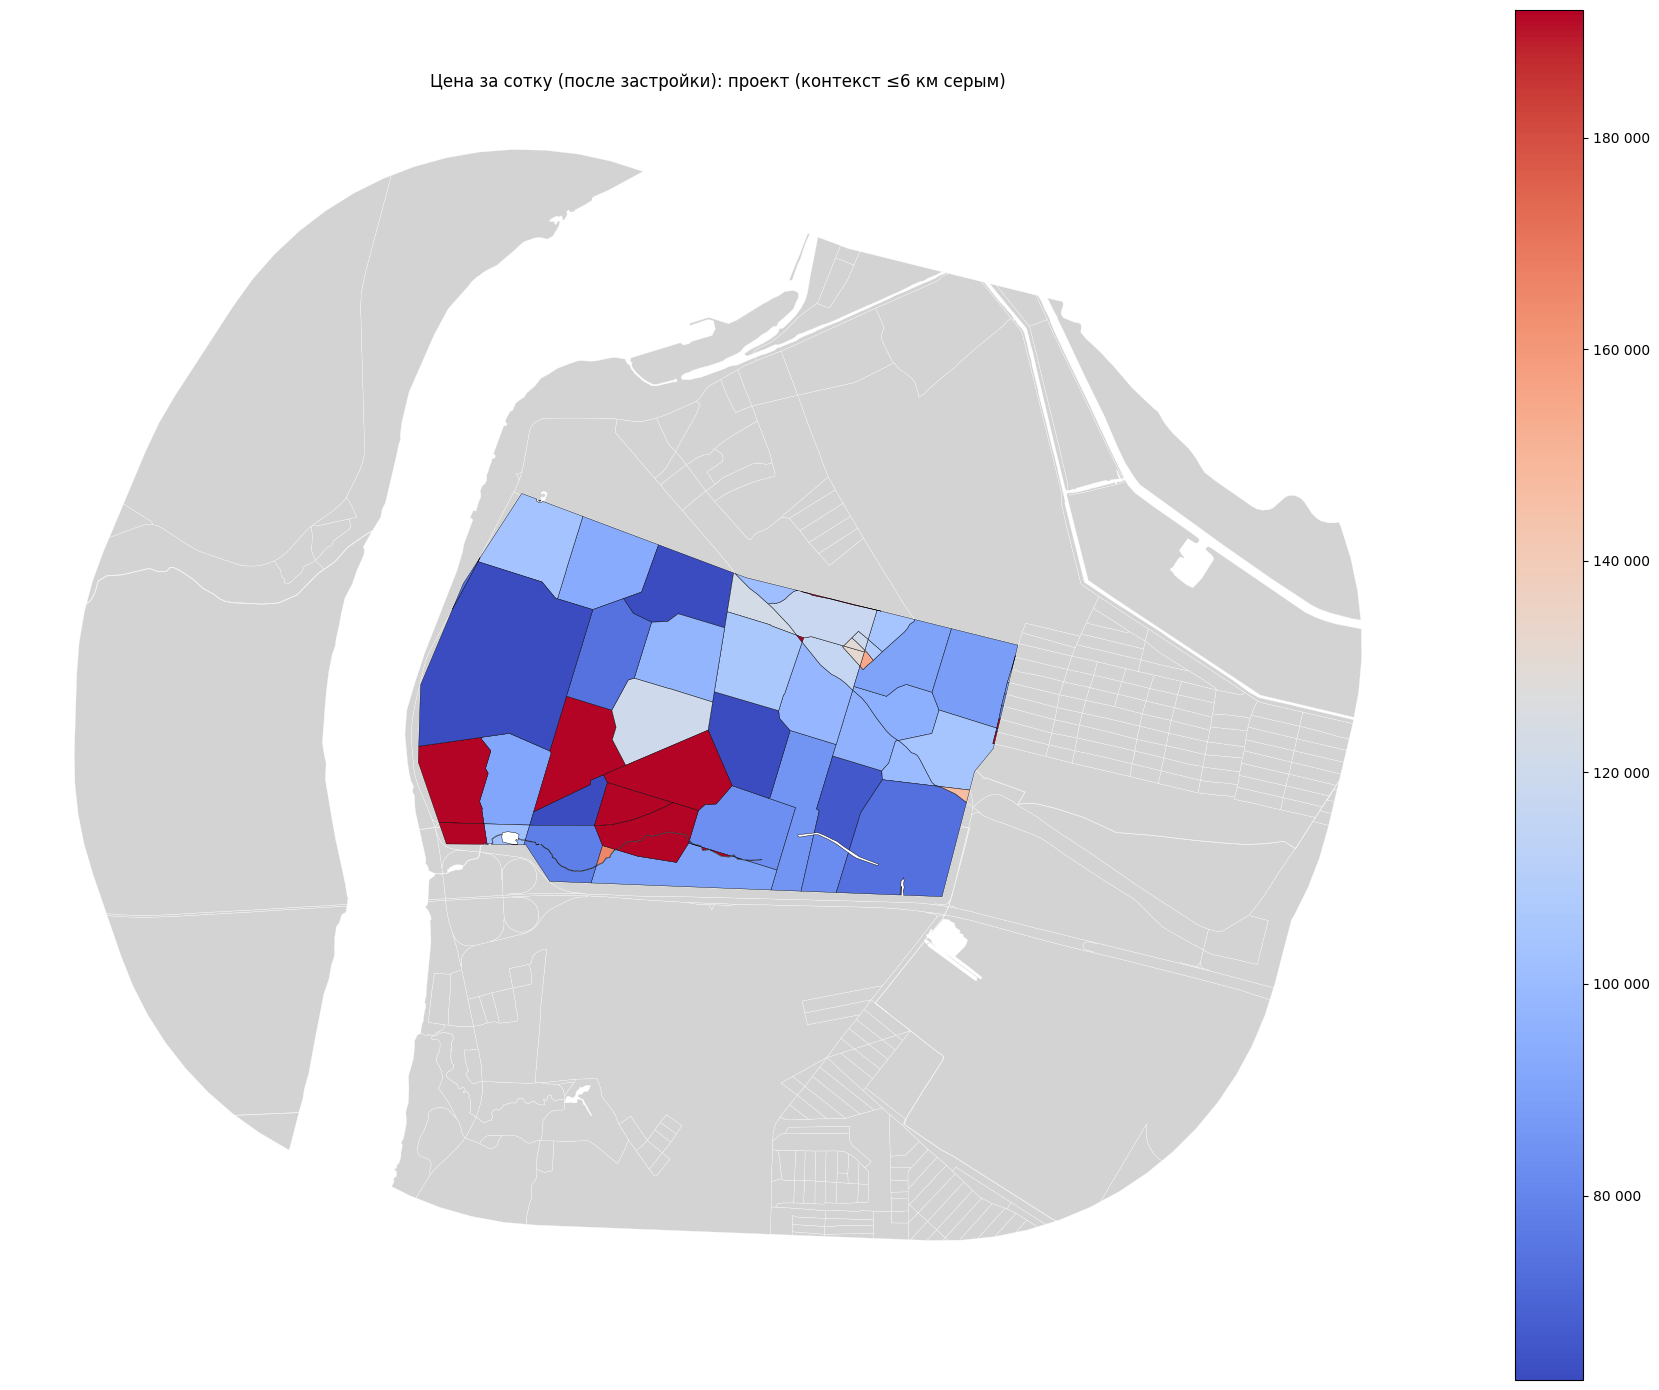

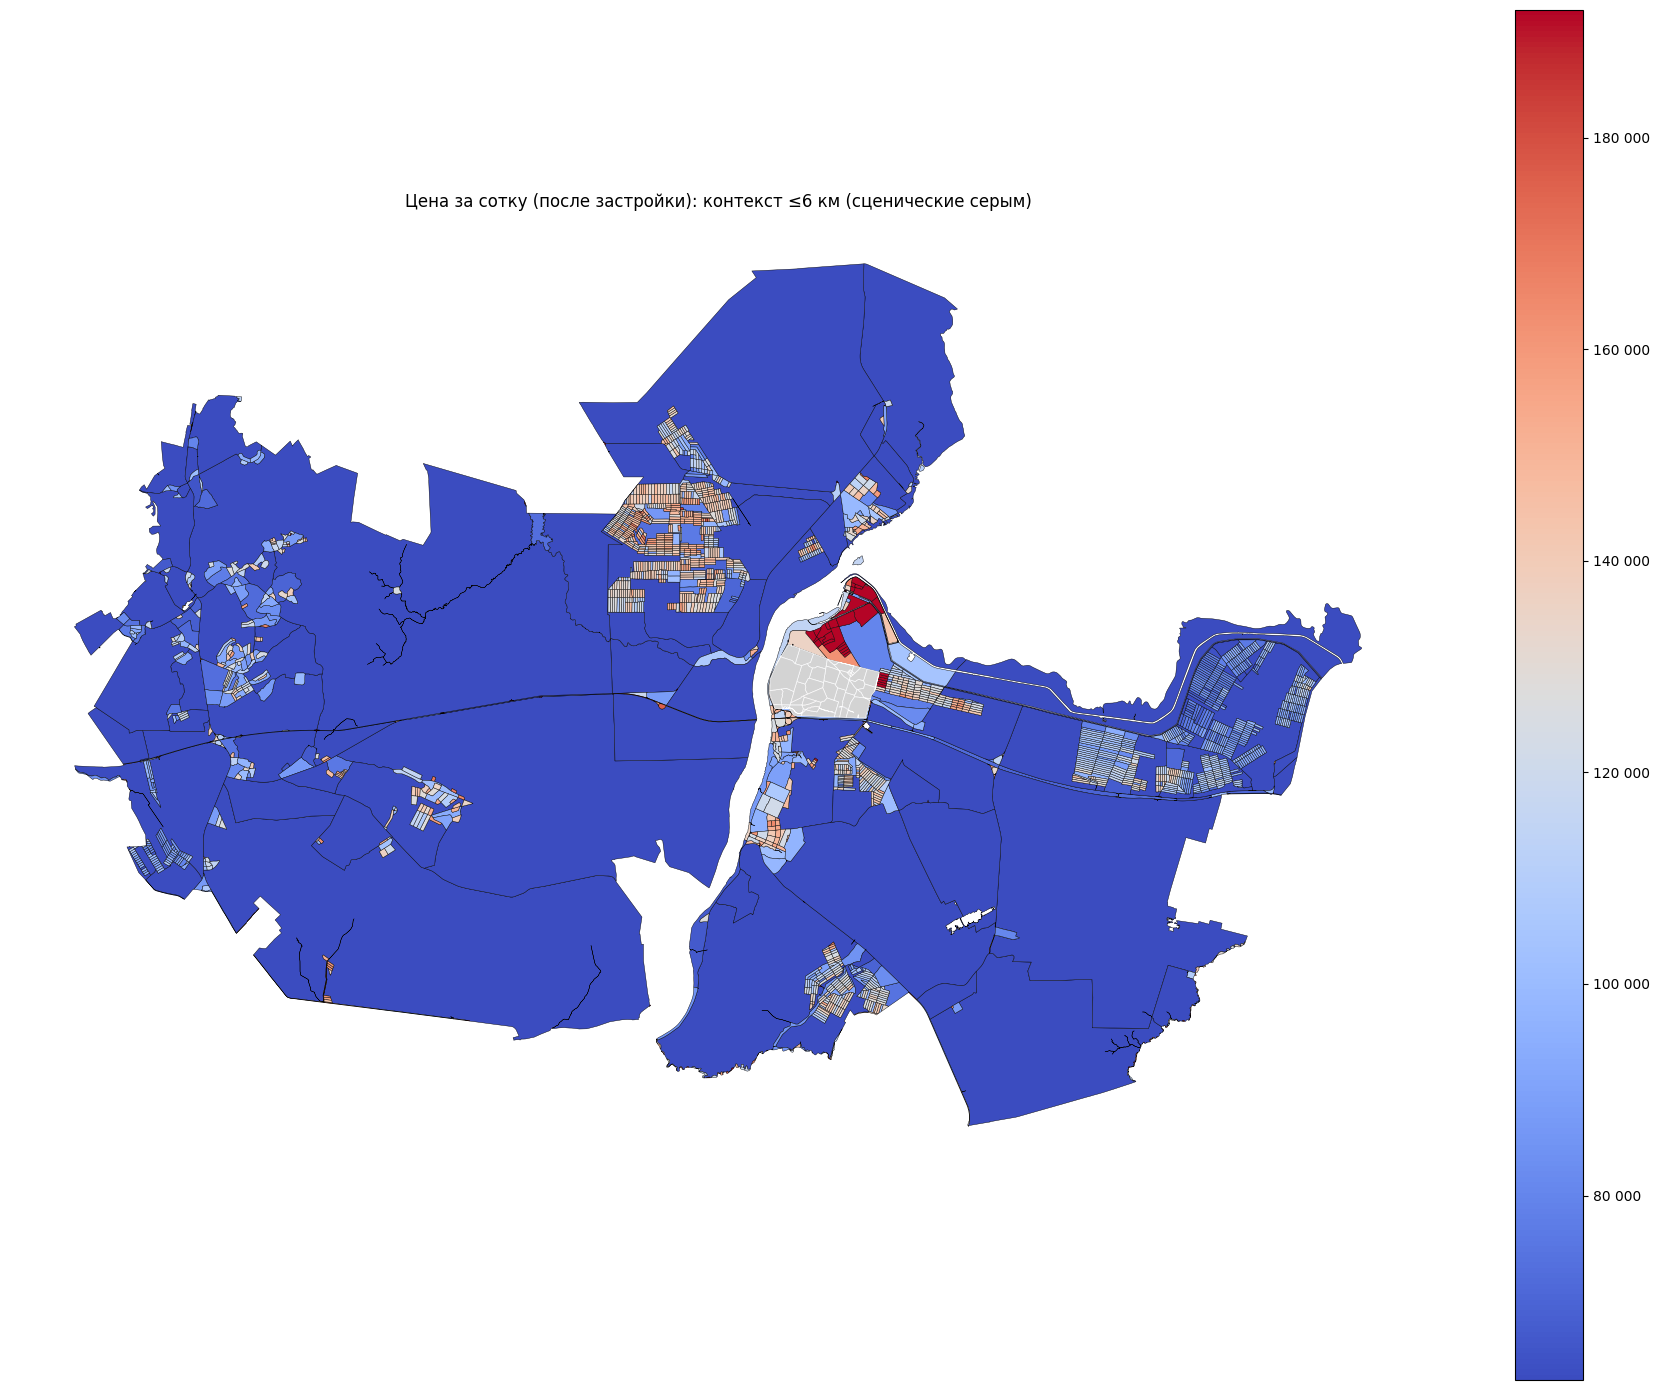

In [14]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_full_value,
    price_column="land_value",  # используйте "land_value_before" для цен до застройки
    buffer_radius_m=2000,
)

In [15]:
m = scn_blocks.explore(
    column='land_value',
    cmap="coolwarm",
    legend=True,
    style_kwds={
        "weight": 0.5,     # толщина границ
        "color": "black",  # цвет границ
        "fillOpacity": 0.7
    },
    name="INV"
)

m

## Сценарий изменения ТЭП участка

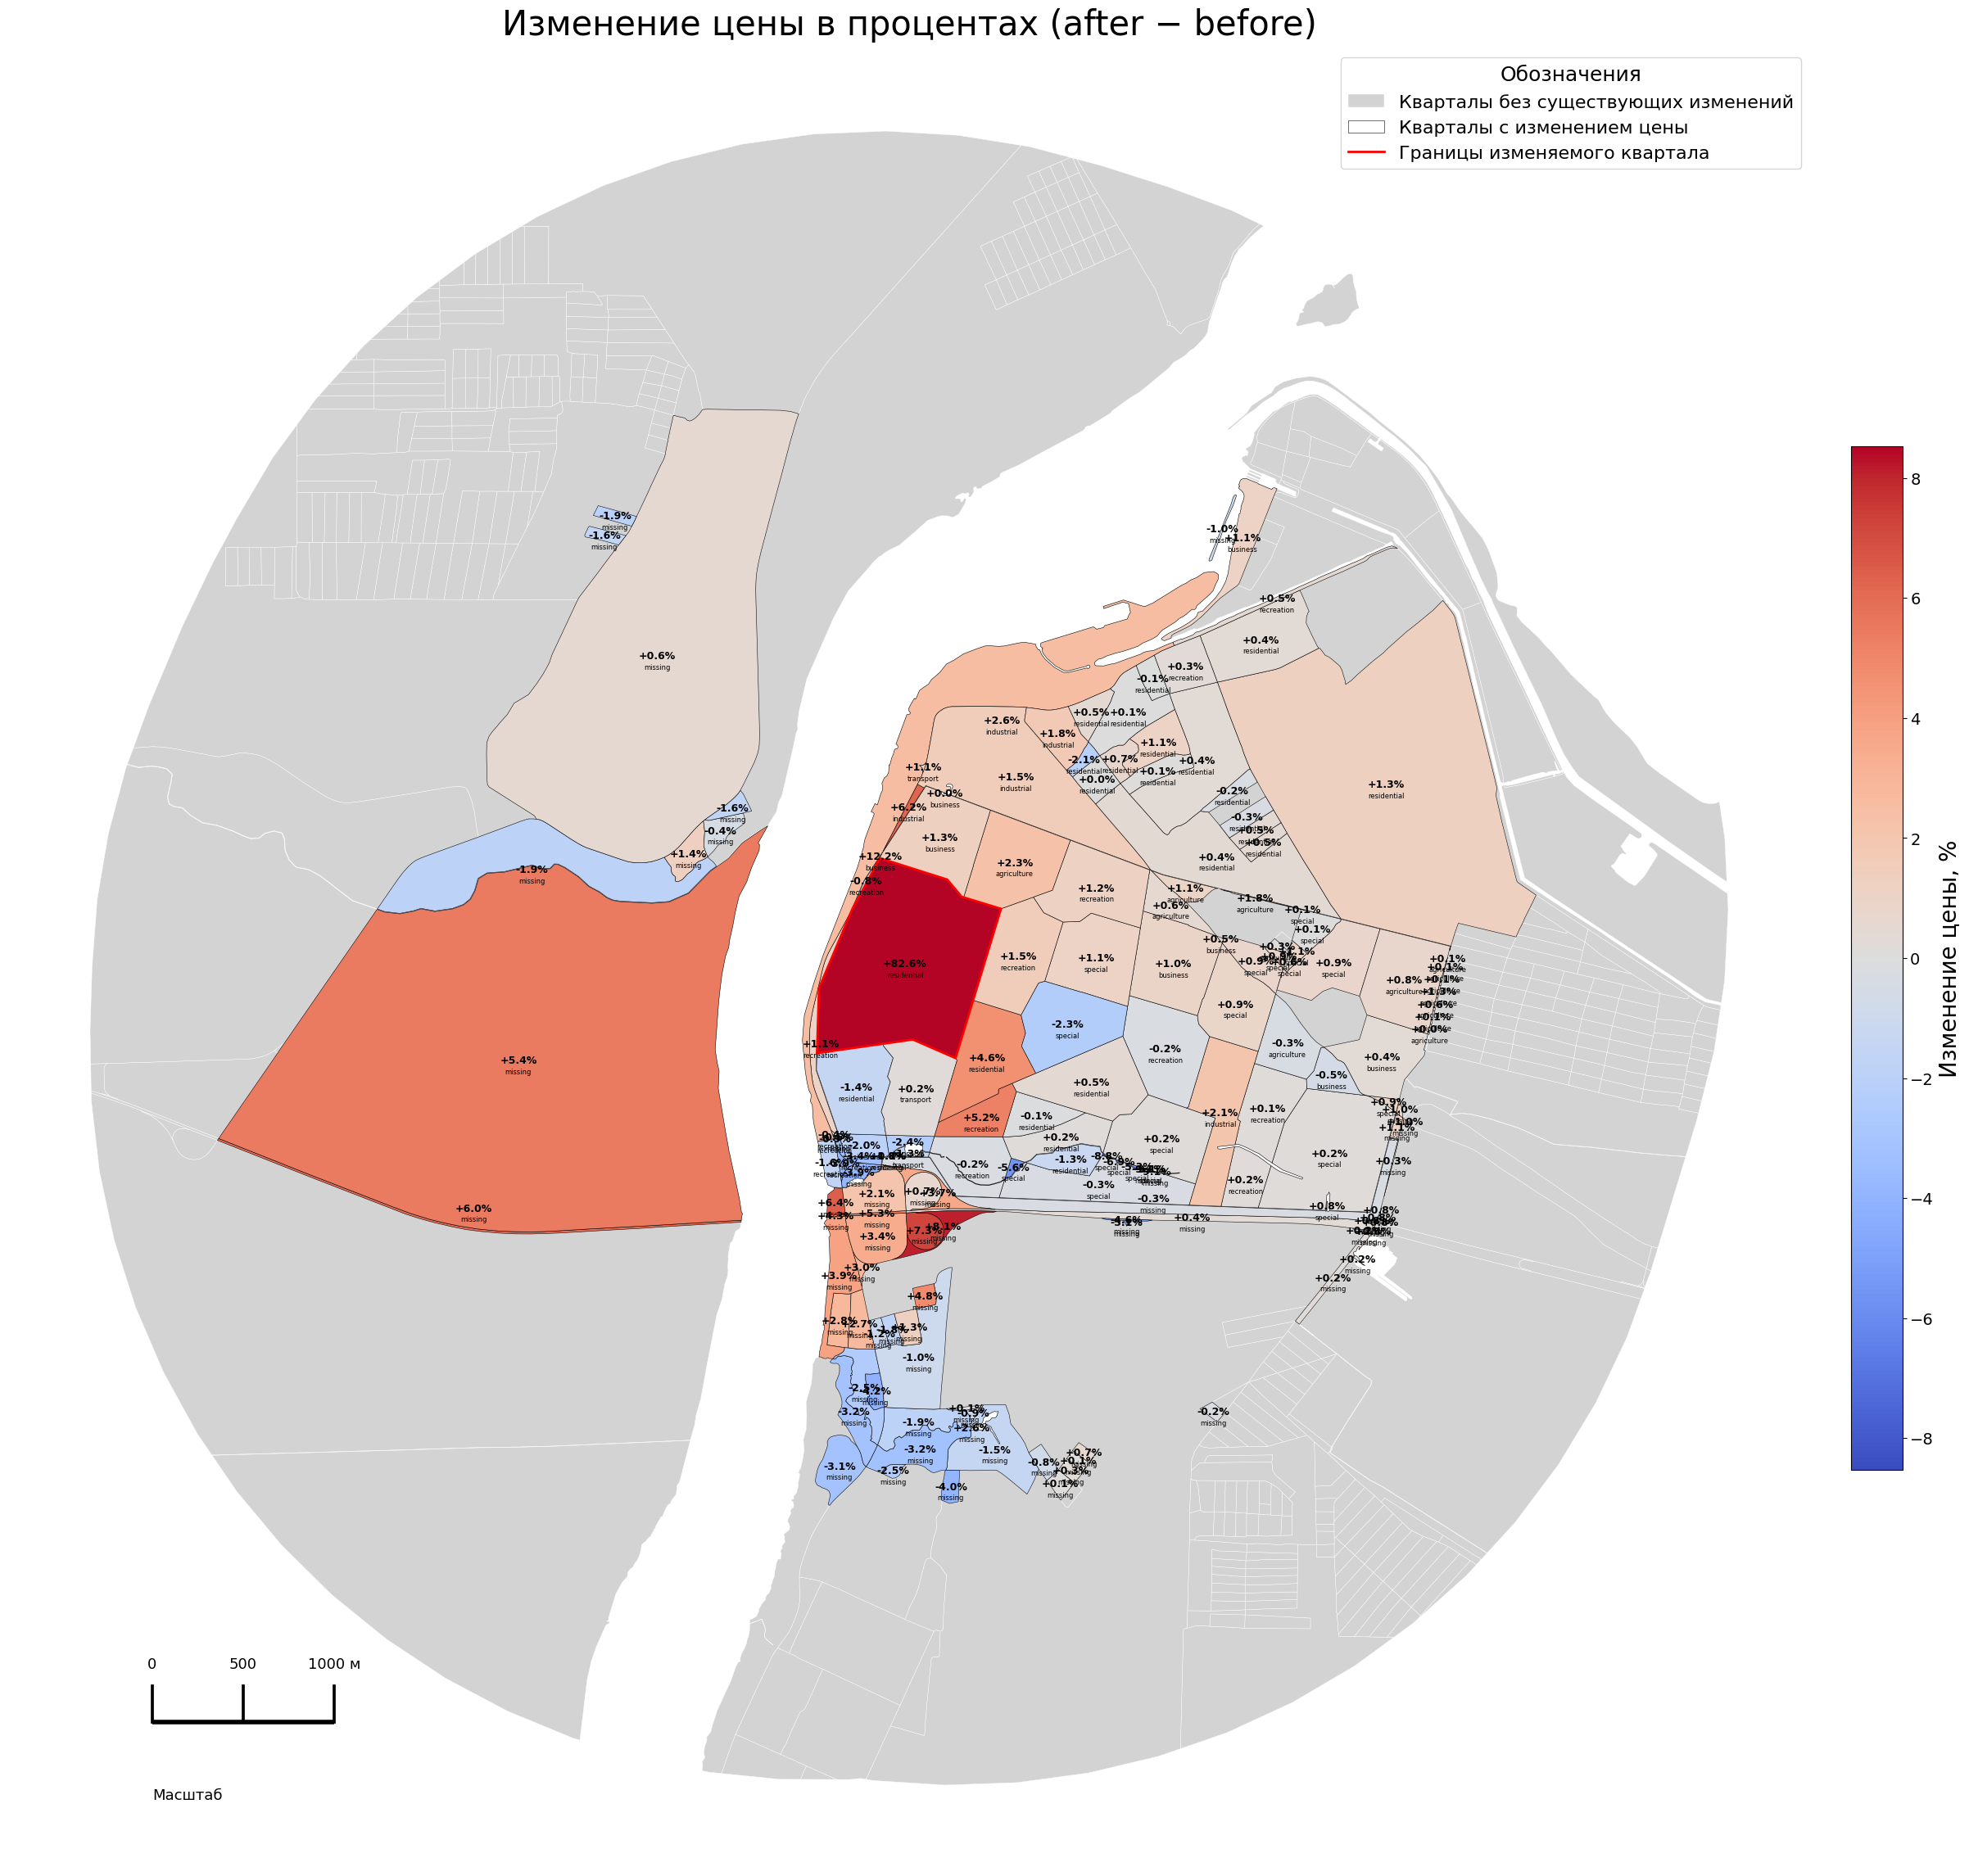


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
62 | residential | 223 337 143 ₽ → 407 776 656 ₽ | +184 439 513 ₽ | +82.6%

Кварталы в границах проекта:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
12 | special | 162 321 450 ₽ → 161 807 582 ₽ | -513 868 ₽ | -0.3%
48 | missing | 58 415 ₽ → 53 092 ₽ | -5 323 ₽ | -9.1%
49 | special | 57 246 ₽ → 52 029 ₽ | -5 217 ₽ | -9.1%
63 | special | 8 287 150 ₽ → 8 364 865 ₽ | +77 716 ₽ | +0.9%
38 | business | 154 660 164 ₽ → 155 270 412 ₽ | +610 248 ₽ | +0.4%
69 | special | 46 663 ₽ → 47 054 ₽ | +391 ₽ | +0.8%
13 | recreation | 51 613 679 ₽ → 51 731 224 ₽ | +117 545 ₽ | +0.2%
40 | special | 274 697 126 ₽ → 275 234 655 ₽ | +537 529 ₽ | +0.2%
14 | recreation | 82 367 707 ₽ → 82 486 216 ₽ | +118 509 ₽ | +0.1%
39 | business | 43 444 744 ₽ → 43 212 758 ₽ | -231 986 ₽ | -0.5%
16 | agriculture | 92 336 583 ₽ → 92 027 811 ₽ | -308 772 ₽ | -0.3%
19 | special | 55 988 961 ₽ → 56 467 0

In [16]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = scenario_blocks
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62 #63

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 25),
)

# Оценка инвестиционной привлекательности

In [17]:
# import requests
# import pandas as pd
# from typing import Final
# from blocksnet.enums import LandUse


# URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

# #211
# #198
# #124
# #335

# id = 198

# scenario_indicators_response = requests.get(
#     f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
# )
# if scenario_indicators_response.status_code != 200:
#     raise Exception("Ошибка при получении индикаторов по сценарию")

# scenario_indicators = scenario_indicators_response.json()

# indicator_attributes = {
#     indicator['indicator']['name_full']: indicator['value']
#     for indicator in scenario_indicators
# }


# LAND_USE_RULES: Final[dict[str, LandUse]] = {
#     'Потенциал развития среднеэтажной жилой застройки': LandUse.RESIDENTIAL,
#     "Потенциал развития застройки общественно-деловой зоны": LandUse.BUSINESS,
#     "Потенциал развития застройки рекреационной зоны": LandUse.RECREATION,
#     "Потенциал развития застройки зоны специального назначения": LandUse.SPECIAL,
#     "Потенциал развития застройки промышленной зоны": LandUse.INDUSTRIAL,
#     "Потенциал развития застройки сельскохозяйственной зоны": LandUse.AGRICULTURE,
#     "Потенциал развития застройки транспортной зоны": LandUse.TRANSPORT,
# }

# records: list[dict[str, object]] = []
# for indicator_name, land_use in LAND_USE_RULES.items():
#     potential = indicator_attributes.get(indicator_name)
#     if potential is None:
#         continue
#     records.append({
#         'land_use': land_use,
#         'potential': potential,
#     })

# potential_df = pd.DataFrame(records).reset_index(drop=True)
# potential_df.to_csv("./data/land_use_potentials.csv", index=False)

# potential_df

In [18]:
from urbanomy.methods.investment_potential import prepare_investment_input
# potential_df = pd.read_csv("./data/land_use_potentials.csv")

scenario_blocks = pd.read_pickle('./data/blocks_full_value.pickle').to_crs(32636)
scenario_blocks = scenario_blocks.loc[scenario_blocks['is_project'] == True].copy()

potential_df = pd.read_csv("./data/land_use_potentials.csv")

In [19]:
investment_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = potential_df,
)

investment_input.head()

2025-12-10 13:52:10.328 | WARNING  | urbanomy.utils.investment_input:_prepare_with_base:347 - prepare_investment_input: у 3 из 70 кварталов нет land-use после нормализации; они остаются в наборе и будут обработаны на следующем этапе.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.AGRICULTURE,1.889022e+08,1.040179e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0
1,LandUse.BUSINESS,2.096246e+08,1.035707e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0
2,LandUse.TRANSPORT,1.502461e+08,8.462455e+07,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0
3,LandUse.RESIDENTIAL,4.697694e+08,8.303549e+07,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,0.0
4,None,4.721626e+04,3.494857e+03,16.489152,0.000000,1.306345,1.306345,1.000000,0.0


In [20]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}


## Вычисляем оценку

In [21]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary


2025-12-10 13:52:10.380 | WARNING  | urbanomy.methods.investment_potential.investment_metrics:calculate_investment_metrics:578 - calculate_investment_metrics: 3 из 70 кварталов без land-use; пропускаем их в расчётах, но оставляем в итоговом отчёте.


Project totals:
 • Land area:          5,759,857.12
 • Built area:         1,426,481.21
 • Land value:         6,218,422,381.53
 • Construction cost:  54,162,061,333.49
 • Investment need:    60,380,483,715.02
 • Spatial potential:  3.13
 • Project NPV:        9,116,643,529.73
 • Project IRR:        0.22
 • Project ROI:        6.51
 • Project PP (yrs):   9.80
 • Project EI:         66.83
 • Project INV score:  71.77


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.AGRICULTURE,202399.73,1.040179e+08,12550.41,1.889022e+08,3.137603e+08,5.026624e+08,-1.971050e+08,0.09,2.92,NaN,0.00,3.0,45.00
1,LandUse.BUSINESS,201529.49,1.035707e+08,40777.54,2.096246e+08,2.242764e+09,2.452389e+09,6.458046e+08,0.23,11.89,10.39,72.27,2.0,65.59
2,LandUse.TRANSPORT,164663.86,8.462455e+07,24985.65,1.502461e+08,4.497417e+08,5.999878e+08,-8.475691e+07,0.15,5.15,NaN,0.00,4.0,35.00
3,LandUse.RESIDENTIAL,161571.83,8.303549e+07,72568.69,4.697694e+08,3.265591e+09,3.735361e+09,1.179521e+09,0.30,4.08,5.05,100.00,0.0,60.00
4,None,NaN,3.494860e+03,NaN,4.721626e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,LandUse.BUSINESS,606.98,1.453714e+06,203.64,1.332765e+06,1.120008e+07,1.253284e+07,3.858749e+06,0.24,11.98,9.95,26.56,2.0,33.59
66,LandUse.AGRICULTURE,2.67,4.800058e+04,NaN,1.075884e+04,NaN,1.075884e+04,-7.305800e+03,0.16,6.18,NaN,0.00,3.0,45.00
67,LandUse.TRANSPORT,4307.66,2.213805e+06,688.58,4.415762e+06,1.239437e+07,1.681013e+07,-2.318174e+06,0.15,5.13,NaN,0.00,4.0,35.00
68,LandUse.BUSINESS,61.63,2.220956e+04,13.49,1.888382e+04,7.417990e+05,7.606828e+05,3.249585e+05,0.27,16.05,8.99,35.81,2.0,40.07


In [22]:
scn = scenario_blocks[['geometry']].join(summary)
scn.to_file('./data/blocks_investment.geojson', driver='GeoJSON')

## Визуализация

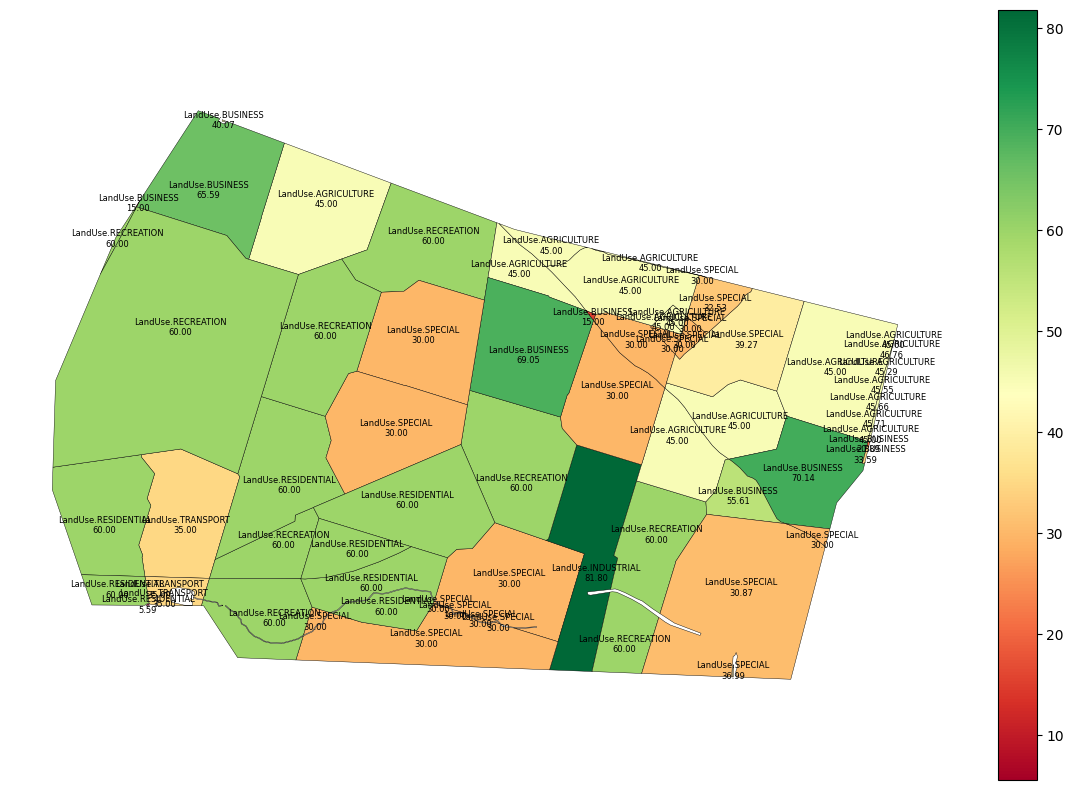

In [23]:
column = "INV"


# ---------- Статичная картинка с тонкими границами ----------
ax = scn.plot(
    column=column,
    cmap="RdYlGn",
    legend=True,
    figsize=(15, 10),
    edgecolor="black",   # цвет границ
    linewidth=0.3        # толщина границ
)

for _, row in scn.dropna(subset=[column]).iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(
        x,
        y,
        f"{row.land_use}\n{row[column]:.2f}",
        ha="center",
        va="center",
        fontsize=6,
        color="black",
    )

ax.set_axis_off()


In [24]:
m = scn.explore(
    column='INV',
    cmap="RdYlGn",
    legend=True,
    style_kwds={
        "weight": 0.5,     # толщина границ
        "color": "black",  # цвет границ
        "fillOpacity": 0.7
    },
    name="INV"
)

m

## Влияние проекта на показатели социально-экономического развития муниципального образования

In [25]:
gdf = gpd.read_file('./data/blocks_investment.geojson')
gdf.head()

,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV,geometry
0,LandUse.AGRICULTURE,202399.73,1.040179e+08,12550.41,1.889022e+08,3.137603e+08,5.026624e+08,-1.971050e+08,0.09,2.92,NaN,0.00,3.0,45.00,"POLYGON ((388511.373 6644951.946, 388558.037 6..."
1,LandUse.BUSINESS,201529.49,1.035707e+08,40777.54,2.096246e+08,2.242764e+09,2.452389e+09,6.458046e+08,0.23,11.89,10.39,72.27,2.0,65.59,"POLYGON ((388558.037 6645102.374, 388511.373 6..."
2,LandUse.TRANSPORT,164663.86,8.462455e+07,24985.65,1.502461e+08,4.497417e+08,5.999878e+08,-8.475691e+07,0.15,5.15,NaN,0.00,4.0,35.00,"POLYGON ((387957.434 6643444.937, 388007.492 6..."
3,LandUse.RESIDENTIAL,161571.83,8.303549e+07,72568.69,4.697694e+08,3.265591e+09,3.735361e+09,1.179521e+09,0.30,4.08,5.05,100.00,0.0,60.00,"POLYGON ((388007.492 6643608.409, 387957.434 6..."
4,None,NaN,3.494860e+03,NaN,4.721626e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((388001.306 6643195.969, 388000.75 66..."


In [26]:
from urbanomy.methods.socio_economic_indicators.constants import (
    DEFAULT_VA_PER_M2_OPS,
    DEFAULT_JOBS_PER_M2,
    DEFAULT_WAGE_BY_USE,
    DEFAULT_PROFIT_SHARE_OPS,
    DEFAULT_CAPEX_CAPITALIZABLE_SHARE,
    DEFAULT_AMORTIZATION_RATES,
)

project_cfg = {  # Эффекты стройки считаем разово по всему проекту

    "population": 520_000,  # Население базовой территорииА
    "employment_share": 0.62,  # Доля занятых в базе (по умолчанию 0.62)
    "avg_wage_base": 74_000,  # Средняя зарплата до проекта
    "build_wage_share": 0.27,  # Доля зарплаты в инвестициях на стройке
    "build_profit_margin": 0.065,  # Рентабельность строительства
    "tax_rates": {  # Налоговые ставки проекта
        "pit": 0.12,  # НДФЛ
        "cit": 0.17,  # налог на прибыль
        "prop": 0.025,  # налог на имущество
        "land": 0.015,  # земельный налог
    },
    "va_coeff_build": {  # Коэффициенты валовой добавленной стоимости на стройке
        "default": 0.50,  # базовый коэффициент для прочих категорий
        "business": 0.55,  # повышаем мультипликатор для деловой застройки
        "special": 0.52,
    },
    "va_per_m2_ops": {  # ВДС на квадратный метр в эксплуатации
        **DEFAULT_VA_PER_M2_OPS,
        "business": 13_500.0,
        "transport": 5_500.0,
    },
    "jobs_per_m2": {  # Рабочие места на квадратный метр
        **DEFAULT_JOBS_PER_M2,
        "business": 1 / 20,
        "special": 1 / 28,
    },
    "wage_by_use": {  # Средние зарплаты по видам использования земли
        **DEFAULT_WAGE_BY_USE,
        "business": 92_000,
        "transport": 63_000,
    },
    "profit_share_ops": {  # Доли прибыли в обороте в эксплуатации
        **DEFAULT_PROFIT_SHARE_OPS,
        "business": 0.20,
        "special": 0.16,
    },
    "capex_capitalizable_share": {  # Доля капзатрат, переходящих в основные средства
        **DEFAULT_CAPEX_CAPITALIZABLE_SHARE,
        "transport": 0.92,
    },
    "amortization_rates": {  # Годовые нормы амортизации
        **DEFAULT_AMORTIZATION_RATES,
        "business": 0.032,
        "special": 0.045,
}}


In [27]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(gdf, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,180 548
1,Валовый региональный продукт на душу населения,107 744
2,Доходы бюджета территории,25 706 035 776
3,Средний уровень заработной платы,928
4,Износ основного фонда (тыс. руб.),1 748 984
